In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [39]:
!wget -O banknote_authentication.csv https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt

--2026-07-23 04:59:20--  https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘banknote_authentication.csv’

banknote_authentica     [ <=>                ]  45.31K  --.-KB/s    in 0.05s   

2026-07-23 04:59:20 (844 KB/s) - ‘banknote_authentication.csv’ saved [46400]



In [40]:
!ls

banknote_authentication.csv  sample_data


In [41]:
import pandas as pd

column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv("banknote_authentication.csv", names=column_names)

In [42]:
from google.colab import files

files.download("banknote_authentication.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# Display the First Five Rows
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [44]:
# Dataset Dimensions
df.shape

(1372, 5)

In [45]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [46]:
# Missing Values
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [47]:
# Descriptive Statistics
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


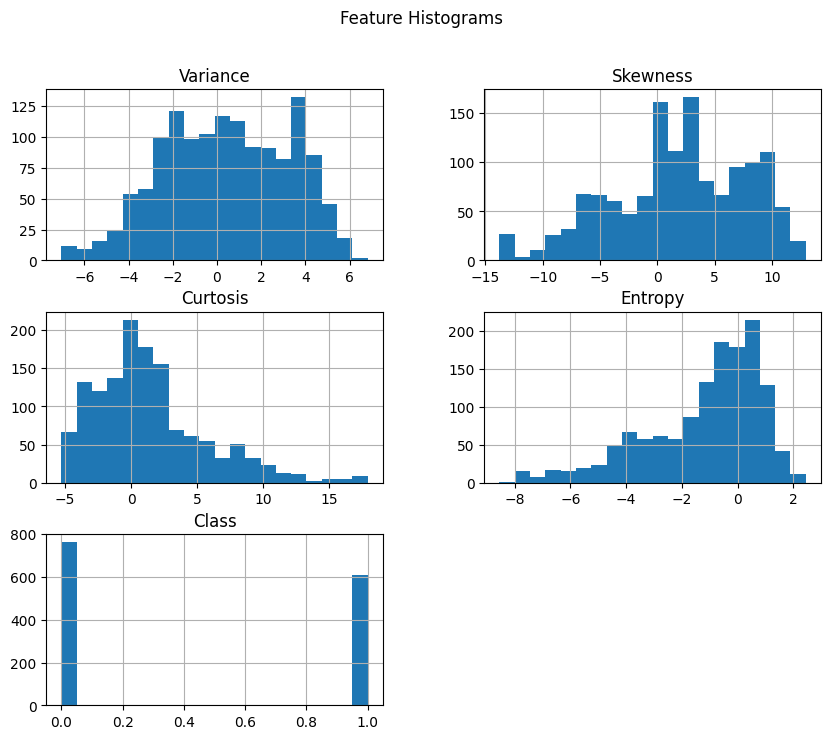

In [48]:
# Plot Histograms
df.hist(figsize=(10, 8), bins=20)

plt.suptitle("Feature Histograms")
plt.show()

# The histograms show the distribution of each feature.
# Some features are skewed, indicating that the values are not evenly distributed across the range.

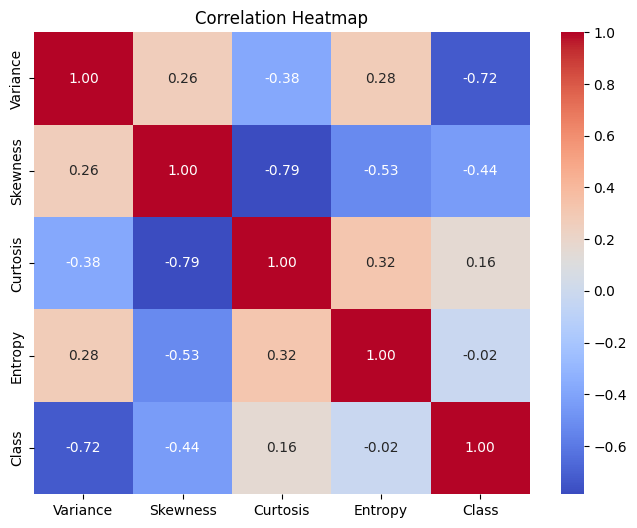

In [49]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# The heatmap shows the relationship between the numerical features.
# Strong positive or negative values indicate highly correlated features, while values close to zero indicate weak relationships.

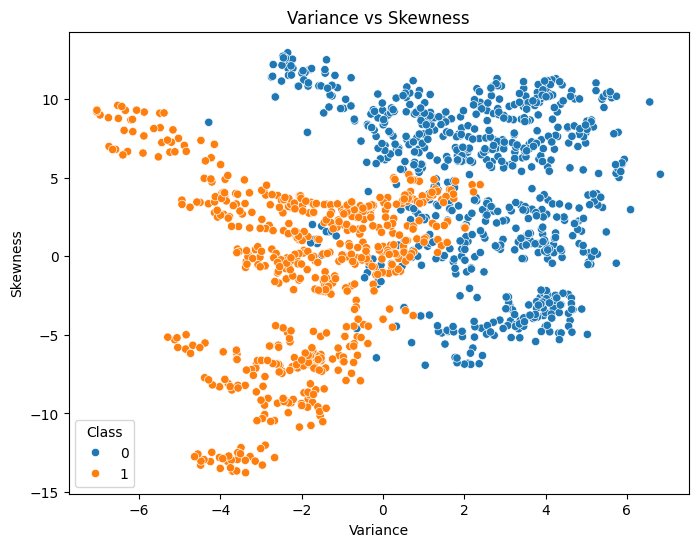

In [50]:
# Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Variance",
    y="Skewness",
    hue="Class",
    data=df
)

plt.title("Variance vs Skewness")
plt.show()
# The scatter plot shows how the two selected features are distributed for each class.
# If the classes occupy different regions with limited overlap, they are approximately linearly separable.

Text(0.5, 1.0, 'Boxplots of Features')

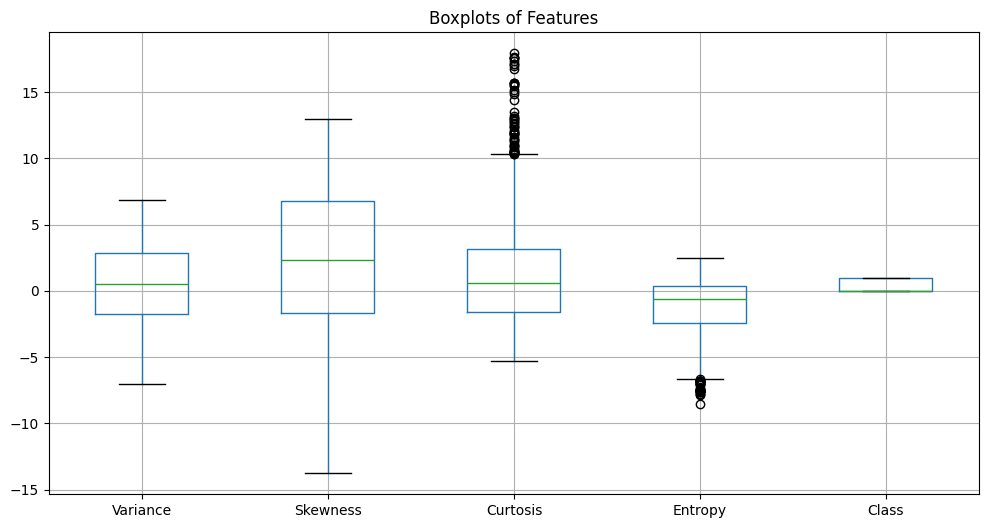

In [51]:
# Boxplots
plt.figure(figsize=(12,6))

df.boxplot()

plt.title("Boxplots of Features")
# plt.show()The boxplots show the spread and median of each feature.
# They also help identify potential outliers that may affect model training.

In [52]:
# Separate Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.head())
print()

print(y.head())

   Variance  Skewness  Curtosis  Entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64


In [53]:
# Split into Training and Testing Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(1097, 4)
(275, 4)


In [54]:
# Normalize the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1097, 4)
Testing Features : (275, 4)
Training Labels  : (1097,)
Testing Labels   : (275,)


In [56]:
# Create the Perceptron Class
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):

        self.learning_rate = learning_rate
        self.epochs = epochs

In [57]:
# Initialize Weights and Bias
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):

        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

    def activation(self, x):
      return 1 if x>= 0 else 0

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation(z)

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors_history = []
        self.weights_history = []
        self.bias_history = []

        for epoch in range(self.epochs):

            errors = 0

            for x_i, target in zip(X, y):

                prediction = self.predict(x_i)

                update = self.learning_rate * (target - prediction)

                self.weights += update * x_i
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors_history.append(errors)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"Epoch {epoch+1}/{self.epochs}")
            print(f"Errors : {errors}")
            print(f"Weights: {self.weights}")
            print(f"Bias   : {self.bias}")
            print("-" * 50)

In [58]:
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

model.fit(X_train, y_train)

Epoch 1/20
Errors : 47
Weights: [-0.06920384 -0.06634441 -0.06529563 -0.00524322]
Bias   : -0.03
--------------------------------------------------
Epoch 2/20
Errors : 22
Weights: [-0.07576842 -0.09439477 -0.05170347 -0.00312988]
Bias   : -0.03
--------------------------------------------------
Epoch 3/20
Errors : 28
Weights: [-0.08628609 -0.10389484 -0.06133036 -0.00617938]
Bias   : -0.03
--------------------------------------------------
Epoch 4/20
Errors : 24
Weights: [-0.09820347 -0.0939408  -0.08818487 -0.01037106]
Bias   : -0.05
--------------------------------------------------
Epoch 5/20
Errors : 29
Weights: [-0.10984895 -0.12095156 -0.08618021  0.0003308 ]
Bias   : -0.04
--------------------------------------------------
Epoch 6/20
Errors : 17
Weights: [-0.10385459 -0.13004831 -0.08702307  0.01372732]
Bias   : -0.05
--------------------------------------------------
Epoch 7/20
Errors : 26
Weights: [-0.10982533 -0.11869946 -0.11825568 -0.01997855]
Bias   : -0.05
---------------

In [59]:
# Predict the test data
y_pred = [model.predict(x) for x in X_test]

print("First 10 Predictions:", y_pred[:10])

First 10 Predictions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [60]:
# Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [61]:
# Calculate the Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [62]:
# Display the Results
print("Model Evaluation")
print("-" * 30)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

Model Evaluation
------------------------------
Accuracy : 0.9818
Precision: 0.9841
Recall   : 0.9764
F1 Score : 0.9802

Confusion Matrix
[[146   2]
 [  3 124]]


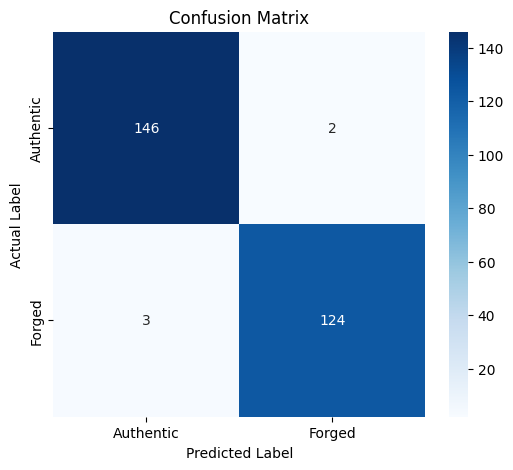

In [63]:
# confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Authentic", "Forged"],
    yticklabels=["Authentic", "Forged"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

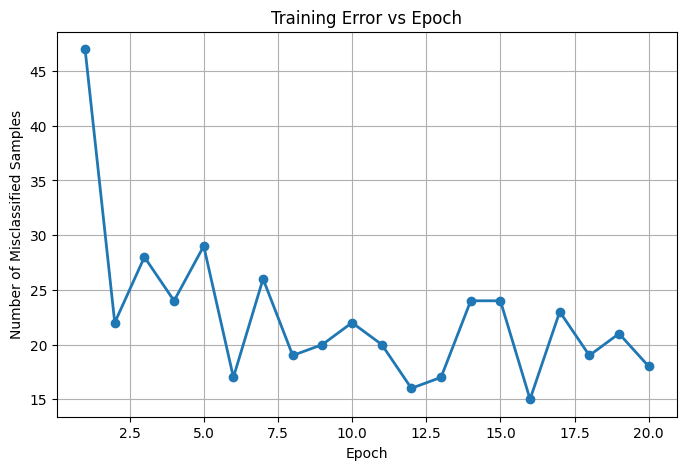

In [64]:
# Training Error vs Epoch
plt.figure(figsize=(8,5))

plt.plot(
    range(1, model.epochs + 1),
    model.errors_history,
    marker='o',
    linewidth=2
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")

plt.grid(True)

plt.show()

# The number of misclassified samples decreases as the number of epochs increases. This indicates that the perceptron gradually learns from its mistakes and converges during training.

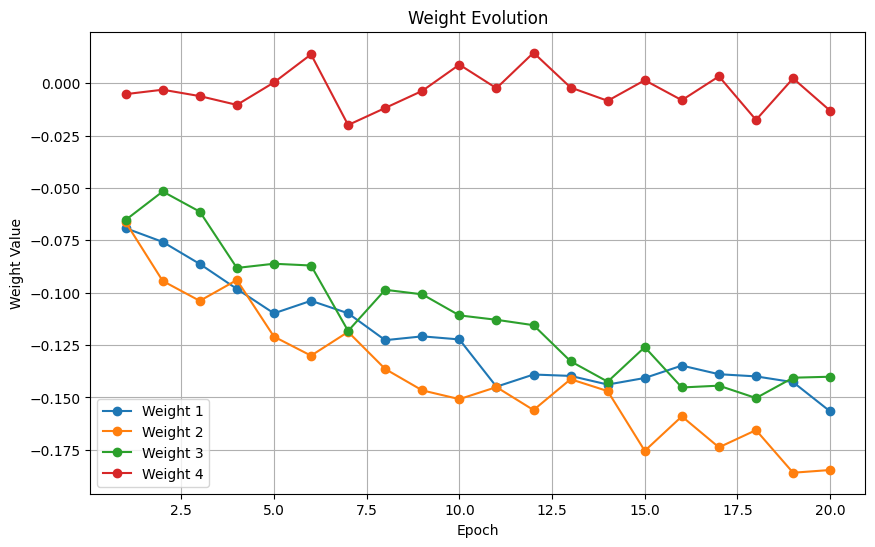

In [65]:
# Weight Evolution
weights = np.array(model.weights_history)

plt.figure(figsize=(10,6))

for i in range(weights.shape[1]):

    plt.plot(
        range(1, model.epochs + 1),
        weights[:, i],
        marker='o',
        label=f"Weight {i+1}"
    )

plt.title("Weight Evolution")

plt.xlabel("Epoch")
plt.ylabel("Weight Value")

plt.legend()
plt.grid(True)

plt.show()
#  The weights change significantly during the initial epochs and gradually stabilize. This indicates that the perceptron converges to suitable parameter values.

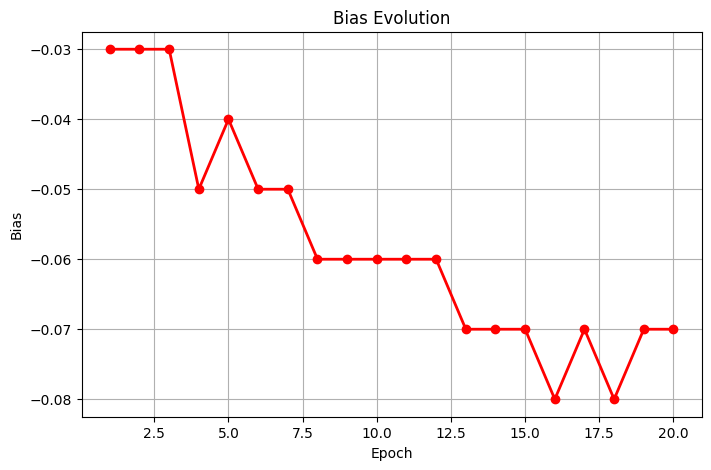

In [68]:
# Bias Evolution
plt.figure(figsize=(8,5))

plt.plot(
    range(1, model.epochs + 1),
    model.bias_history,
    marker='o',
    color='red',
    linewidth=2
)

plt.title("Bias Evolution")

plt.xlabel("Epoch")
plt.ylabel("Bias")

plt.grid(True)

plt.show()
# The bias value changes during training and stabilizes after several epochs, helping the perceptron correctly position the decision boundary.

Epoch 1/20
Errors : 47
Weights: [-0.00692038 -0.00663444 -0.00652956 -0.00052432]
Bias   : -0.003
--------------------------------------------------
Epoch 2/20
Errors : 22
Weights: [-0.00757684 -0.00943948 -0.00517035 -0.00031299]
Bias   : -0.003
--------------------------------------------------
Epoch 3/20
Errors : 28
Weights: [-0.00862861 -0.01038948 -0.00613304 -0.00061794]
Bias   : -0.003
--------------------------------------------------
Epoch 4/20
Errors : 24
Weights: [-0.00982035 -0.00939408 -0.00881849 -0.00103711]
Bias   : -0.005
--------------------------------------------------
Epoch 5/20
Errors : 29
Weights: [-1.09848954e-02 -1.20951565e-02 -8.61802072e-03  3.30799957e-05]
Bias   : -0.004
--------------------------------------------------
Epoch 6/20
Errors : 17
Weights: [-0.01038546 -0.01300483 -0.00870231  0.00137273]
Bias   : -0.005
--------------------------------------------------
Epoch 7/20
Errors : 26
Weights: [-0.01098253 -0.01186995 -0.01182557 -0.00199786]
Bias   :

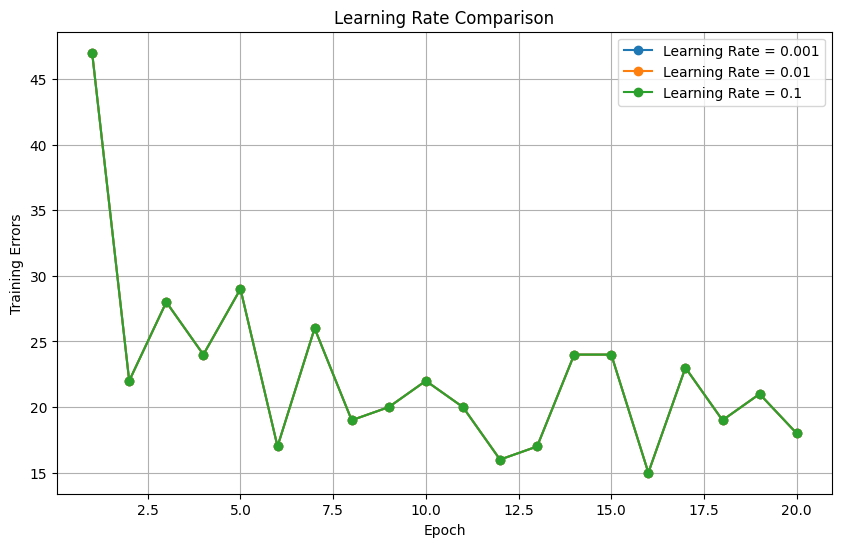

In [69]:
# Learning Rate Comparison
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10,6))

for lr in learning_rates:

    temp_model = Perceptron(
        learning_rate=lr,
        epochs=20
    )

    temp_model.fit(X_train, y_train)

    plt.plot(
        range(1, temp_model.epochs + 1),
        temp_model.errors_history,
        marker='o',
        label=f"Learning Rate = {lr}"
    )

plt.title("Learning Rate Comparison")

plt.xlabel("Epoch")
plt.ylabel("Training Errors")

plt.legend()

plt.grid(True)

plt.show()
# A smaller learning rate results in slower learning, while a larger learning rate converges faster. The learning rate of 0.01 provides a good balance between convergence speed and stability.